# Jet shear-layer beam example

A finite-width complex-source beam crosses a parallel jet with a Görtler-type velocity profile. Four cases are computed from the combinations $\lambda=1,0.5$ and $\delta=3,6$ at peak Mach number $M_j=0.5$.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import hankel1e

from vortex2dscatter import GAMMA, VortexScatter2D

In [2]:
mach_peak = 0.5
domain_half_width = 10.0
mesh_size = 320
beam_waist = 1.8
beam_source_y = -5.5
beam_center_x = 0.0
beam_angle_deg = -10.0

cases = [
    dict(name="m5_l1_d3", wavelength=1.0, delta=3.0),
    dict(name="m5_l1_d6", wavelength=1.0, delta=6.0),
    dict(name="m5_ld5_d3", wavelength=0.5, delta=3.0),
    dict(name="m5_ld5_d6", wavelength=0.5, delta=6.0),
]

## Jet profile and incident beam

The mean flow is $U(y)=M_J\operatorname{sech}^2(y/\delta)$ with $V=0$.

In [3]:
def gortler_jet_profile(y, delta):
    eta = y / delta
    return mach_peak / np.cosh(eta) ** 2

def gortler_jet_dudy(y, delta):
    eta = y / delta
    sech2 = 1 / np.cosh(eta) ** 2
    return -2 * mach_peak * sech2 * np.tanh(eta) / delta

def complex_source_beam(x, y, k):
    theta = np.deg2rad(beam_angle_deg)
    xi = (x - beam_center_x) * np.sin(theta) + (y - beam_source_y) * np.cos(theta)
    eta = (x - beam_center_x) * np.cos(theta) - (y - beam_source_y) * np.sin(theta)
    rayleigh_length = 0.5 * k * beam_waist**2
    complex_distance = np.sqrt(eta**2 + (xi - 1j * rayleigh_length) ** 2)
    complex_distance = np.where(np.imag(complex_distance) > 0, -complex_distance, complex_distance)
    z = k * complex_distance
    field = hankel1e(0, z) * np.exp(1j * z - k * rayleigh_length)
    return field / np.abs(field).max()

In [ ]:
results = []
for case in cases:
    delta = case["delta"]
    solver = VortexScatter2D(case["wavelength"])
    solver.init_mesh(domain_half_width, mesh_size)
    solver.set_velocity(
        lambda x, y, delta=delta: gortler_jet_profile(y, delta),
        lambda x, y: np.zeros_like(y),
        dudx=lambda x, y: np.zeros_like(x),
        dudy=lambda x, y, delta=delta: gortler_jet_dudy(y, delta),
        dvdx=lambda x, y: np.zeros_like(x),
        dvdy=lambda x, y: np.zeros_like(x),
    )
    solver.set_c2inv(1 / (1 - 0.5 * (GAMMA - 1) * solver.U**2))
    incident = complex_source_beam(solver.x, solver.y, solver.k)
    solver.set_incident(incident).complete()
    solver.solve(maxiter=20, tol=1e-5)
    results.append(dict(case=case, solver=solver, incident=incident))

[(item["case"]["name"], len(item["solver"].residual), item["solver"].residual[-1]) for item in results]

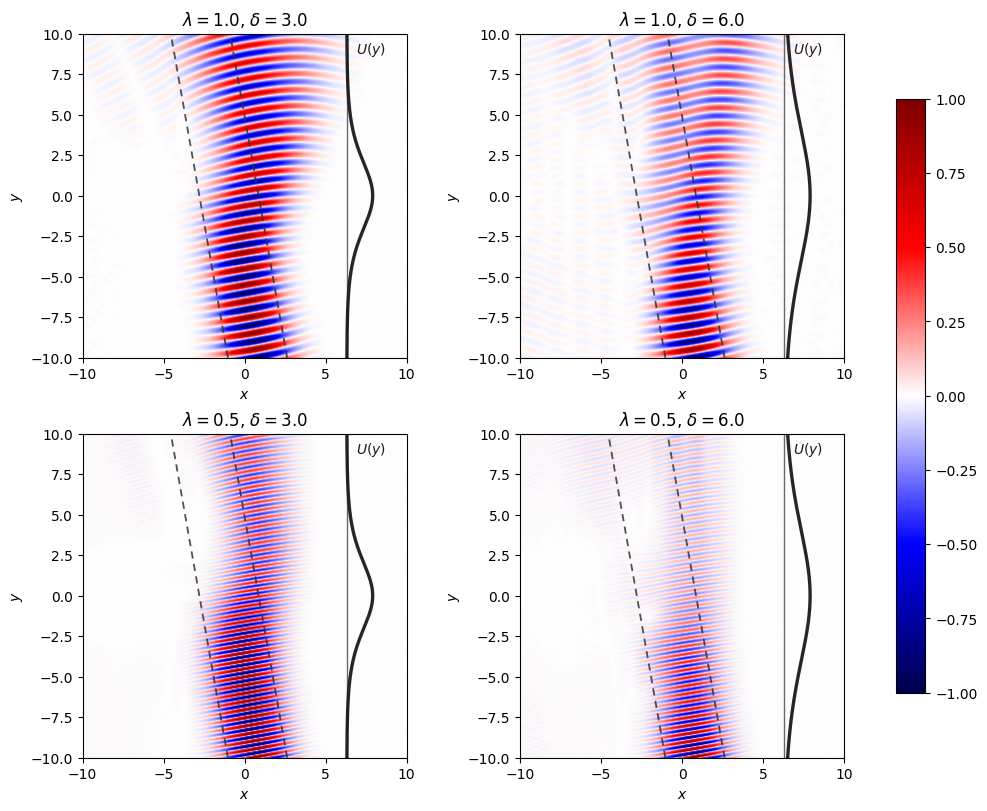

In [5]:
def add_incident_beam_edges(ax):
    theta = np.deg2rad(beam_angle_deg)
    y_abs = np.linspace(-domain_half_width, domain_half_width, 500)
    for eta in (-beam_waist, beam_waist):
        x_abs = beam_center_x + (eta + (y_abs - beam_source_y) * np.sin(theta)) / np.cos(theta)
        ax.plot(x_abs, y_abs, color="0.2", linestyle=(0, (4, 3)), linewidth=1.3, alpha=0.85)

def add_velocity_profile(ax, solver):
    y1d = solver.y[0, :]
    x_ref = 6.3
    x_profile = x_ref + 1.6 * solver.U[solver.mesh_size // 2, :] * 2
    ax.plot([x_ref, x_ref], [y1d[0], y1d[-1]], color="0.1", linewidth=1.0, alpha=0.65)
    ax.plot(x_profile, y1d, color="0.1", linewidth=2.4, alpha=0.95)
    ax.text(x_ref + 0.55, y1d[-1] - 0.35, r"$U(y)$", color="0.1", ha="left", va="top")

fig, axs = plt.subplots(2, 2, figsize=(10.0, 8.0), constrained_layout=True)
for ax, item in zip(axs.flat, results):
    case = item["case"]
    solver = item["solver"]
    im = ax.pcolormesh(
        solver.x,
        solver.y,
        solver.p_total.real,
        vmin=-1.0,
        vmax=1.0,
        shading="gouraud",
        cmap="seismic",
        rasterized=True,
    )
    add_incident_beam_edges(ax)
    add_velocity_profile(ax, solver)
    ax.set_xlim(-10, 10)
    ax.set_ylim(-10, 10)
    ax.set_aspect("equal")
    ax.set_xlabel(r"$x$")
    ax.set_ylabel(r"$y$")
    ax.set_title(rf"$\lambda={case['wavelength']}$, $\delta={case['delta']}$")
fig.colorbar(im, ax=axs, shrink=0.82)